In [1]:
import polars as pl, numpy as np
import duckdb
import matplotlib.pyplot as plt, seaborn as sns
import folium
from folium.plugins import HeatMap
sns.set_theme(style="whitegrid")
pl.Config(fmt_str_lengths=50, tbl_rows=20)

import requests

In [2]:
con = duckdb.connect("data/airbnb.duckdb", read_only=True)

lf = pl.scan_parquet("data/interim/master_all_cities.parquet") # This return lazy frame rather dataframe, cause the low memeory use.

df = ( 
    lf.with_columns(
        pl.col("snapshot_date").str.to_date(strict=False).alias("snap"),
        pl.col("host_since").cast(pl.Utf8).str.to_date(strict=False).alias("hs"),
    )
    .with_columns(
        (pl.col("snap") - pl.col("hs")).alias("year_diff")
    )
    .with_columns(
        pl.when(pl.col("year_diff").dt.total_days() > 1460)
            .then(pl.col("year_diff").dt.total_days() / 365.25)
            .otherwise(pl.col("year_diff").dt.total_days() / 365)
            .round(2)
            .alias("host_tenure_years")
    )
     .collect()
     )

CENTRES = {
    row["city_key"]: (row["lat"], row["lon"])
    for row in (
        df.group_by("city_key")
          .agg(
              pl.col("latitude").median().alias("lat"),
              pl.col("longitude").median().alias("lon"),
          )
          .to_dicts()
    )
}

NUMERIC = [
    c
    for c, dtype in df.schema.items()
    if dtype in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64,
    )
]

print(df.shape, "rows loaded")

(40544, 116) rows loaded


# 4.1 Summary Statistics & Distribution

In [3]:
stats = df.select([
    *[pl.col(c).mean().alias(f"{c}__mean") for c in NUMERIC],
    *[pl.col(c).median().alias(f"{c}__median") for c in NUMERIC],
    *[pl.col(c).std().alias(f"{c}__std") for c in NUMERIC],
    *[pl.col(c).skew().alias(f"{c}__skew") for c in NUMERIC],
    *[pl.col(c).quantile(0.95).alias(f"{c}__p95") for c in NUMERIC],
    *[pl.col(c).null_count().alias(f"{c}__nulls") for c in NUMERIC],
])

In [4]:
tidy = (stats.transpose(include_header=True, header_name="k", column_names=["v"])
        .with_columns(pl.col("k").str.split_exact("__", 1))
        .unnest("k").rename({"field_0":"variable","field_1":"stat"})
        .pivot(values="v", index="variable", on="stat"))
tidy.head(10)

variable,mean,median,std,skew,p95,nulls
str,f64,f64,f64,f64,f64,f64
"""accommodates""",4.551697,4.0,2.717298,1.112919,10.0,0.0
"""availability_30""",11.490899,8.0,11.081024,0.460403,29.0,0.0
"""availability_365""",171.473116,164.0,129.51052,0.098246,364.0,0.0
"""availability_60""",24.619919,18.0,22.62678,0.35506,59.0,0.0
"""availability_90""",40.478098,36.0,33.680166,0.184284,89.0,0.0
"""availability_eoy""",95.686686,92.0,69.458668,-0.005788,197.0,0.0
"""bedrooms""",2.408069,2.0,1.352816,1.45139,5.0,5175.0
"""bedrooms_filled""",2.368242,2.0,1.272177,1.613857,5.0,0.0
"""beds""",3.174471,3.0,2.253285,1.937518,7.0,8149.0


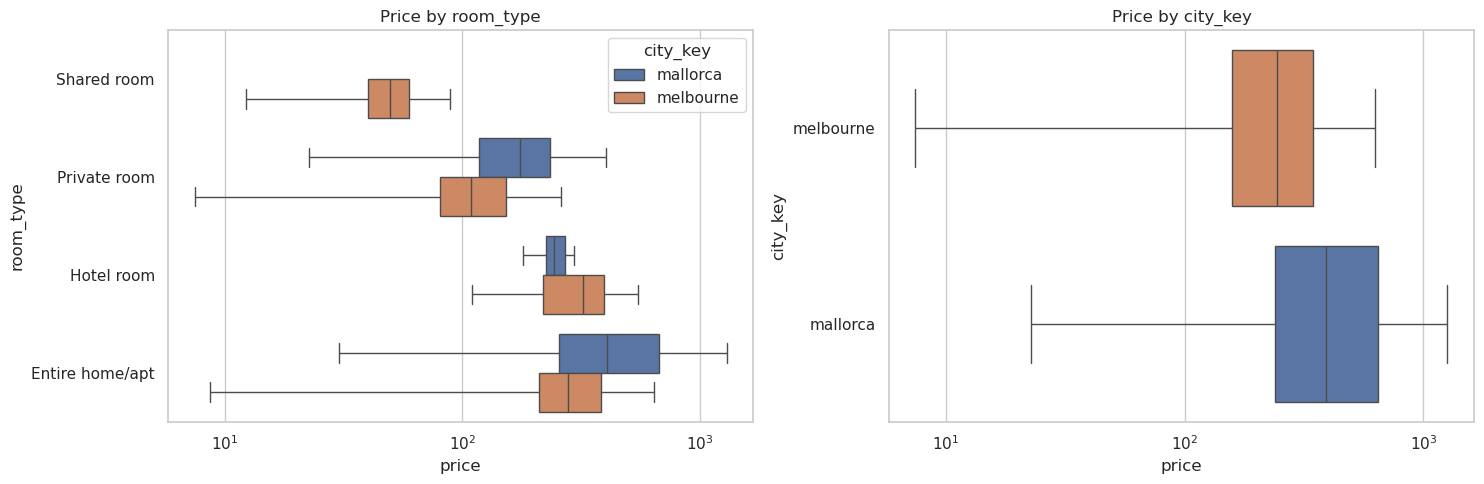

In [5]:
pdf = (
    df.filter(
        pl.col("price").is_not_null() &
        (pl.col("price") < df["price"].quantile(0.99))
    )
    .to_pandas()
)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes

cols = [
    "room_type",
    "city_key"
]

for ax, col in zip(axes, cols):
    order = pdf.groupby(col)["price"].median().sort_values().index

    sns.boxplot(
        data=pdf,
        x="price",
        y=col,
        hue="city_key",
        order=order,
        ax=ax,
        showfliers=False,
    )

    ax.set_xscale("log")
    ax.set_title(f"Price by {col}")


plt.tight_layout()

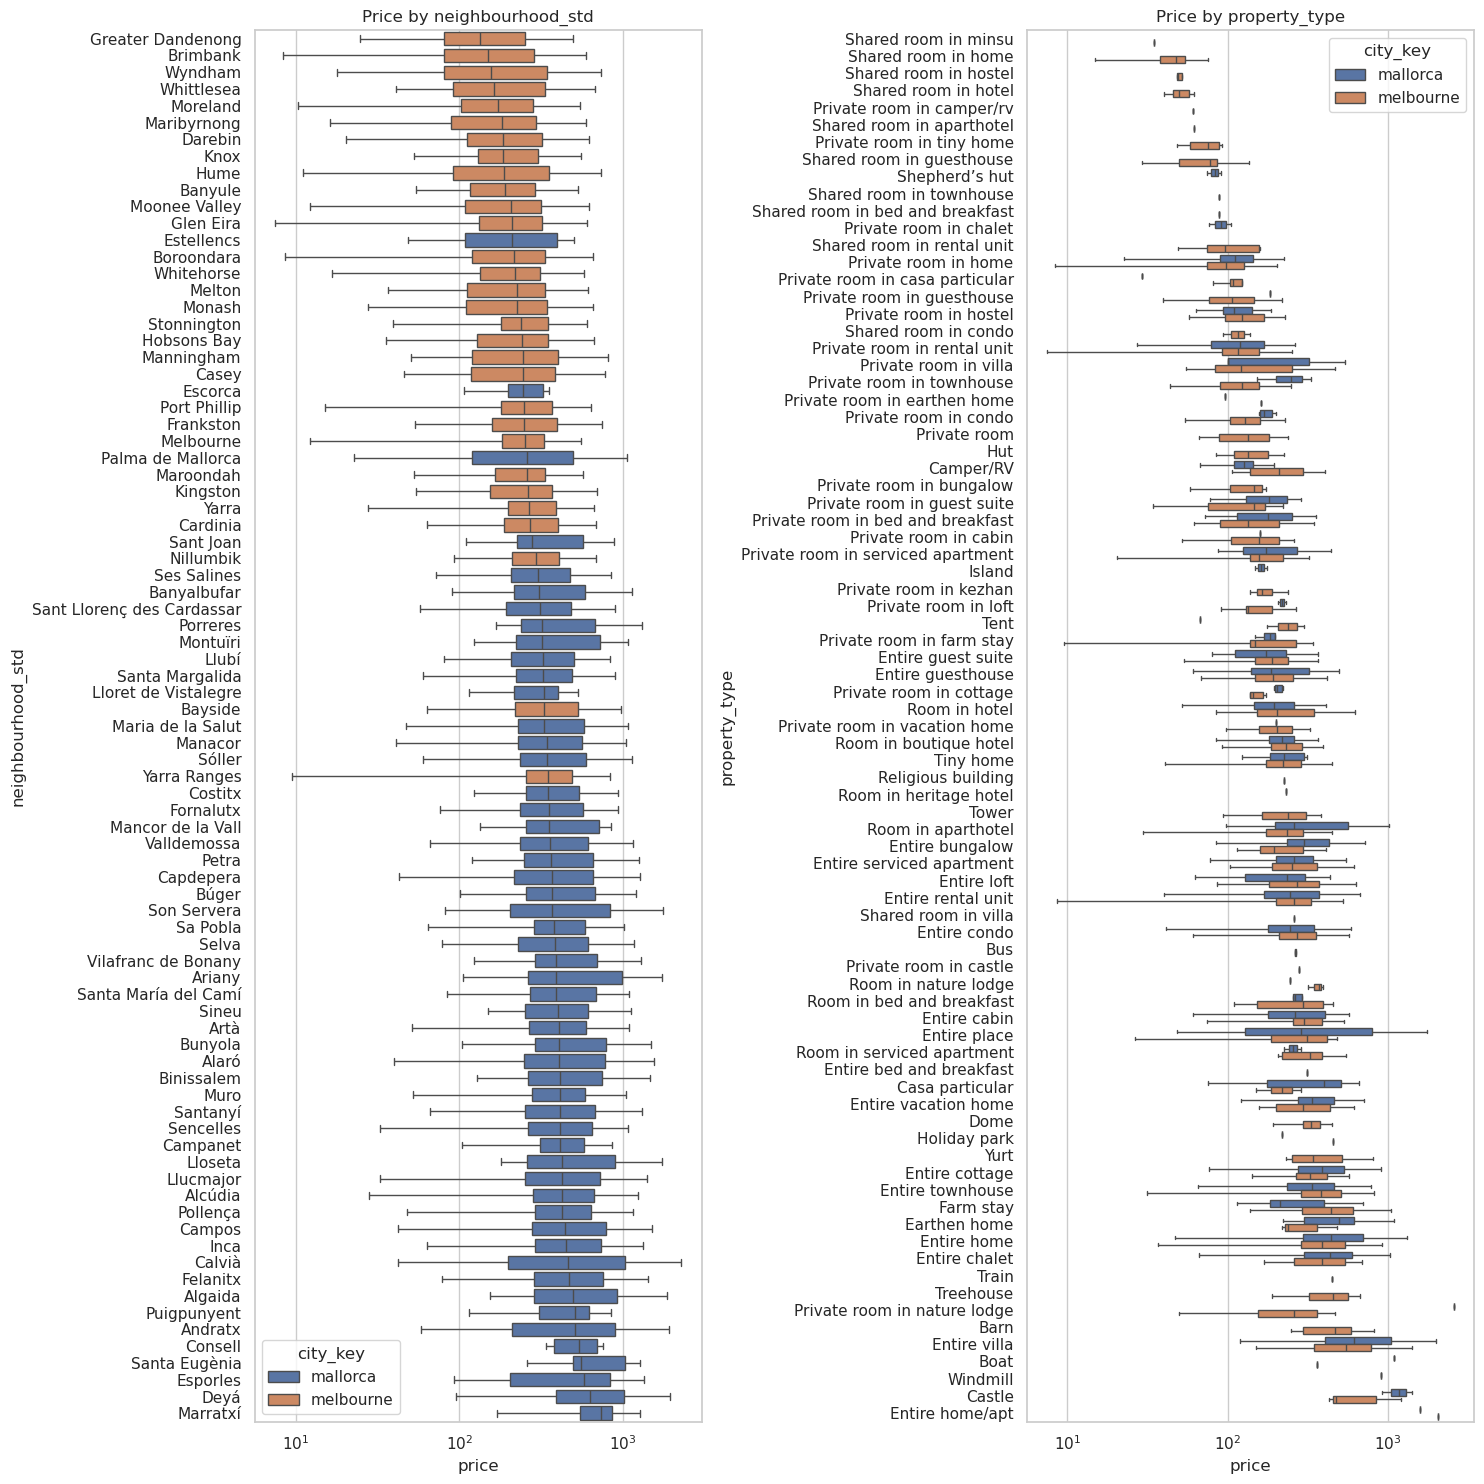

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 15))
axes = axes

cols = [
    "neighbourhood_std",
    "property_type"
]

for ax, col in zip(axes, cols):
    order = pdf.groupby(col)["price"].median().sort_values().index

    sns.boxplot(
        data=pdf,
        x="price",
        y=col,
        hue="city_key",
        order=order,
        ax=ax,
        showfliers=False,
    )

    ax.set_xscale("log")
    ax.set_title(f"Price by {col}")


plt.tight_layout()

single-listing hosts: 78.5%  |  top 1% of hosts hold 28.0% of listings


Text(0.5, 1.0, 'Listings-per-host')

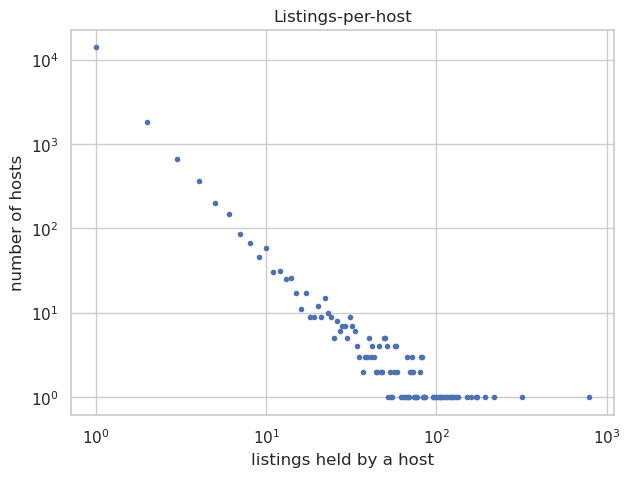

In [7]:
per_host = (
    df.group_by("host_id")
        .agg(n = pl.len())
        .sort("n", descending = True)
)

total = per_host["n"].sum()

single = (per_host["n"]==1).mean()

top1 = per_host.head(max(1,int(len(per_host)*0.01)))["n"].sum()/total

print(f"single-listing hosts: {single:.1%}  |  top 1% of hosts hold {top1:.1%} of listings")

freq = per_host.group_by("n").agg(hosts=pl.len()).sort("n").to_pandas()

plt.figure(figsize=(7,5))
plt.loglog(freq["n"], freq["hosts"], ".")
plt.xlabel("listings held by a host"); plt.ylabel("number of hosts")
plt.title("Listings-per-host")

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 32859.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 4.723802 │
│ std        ┆ 0.415093 │
│ min        ┆ 1.0      │
│ 25%        ┆ 4.65     │
│ 50%        ┆ 4.84     │
│ 75%        ┆ 4.98     │
│ max        ┆ 5.0      │
└────────────┴──────────┘
share ≥ 4.5: 85.4%   share ≥ 4.9: 40.7%


Text(0.5, 1.0, 'Review score distribution')

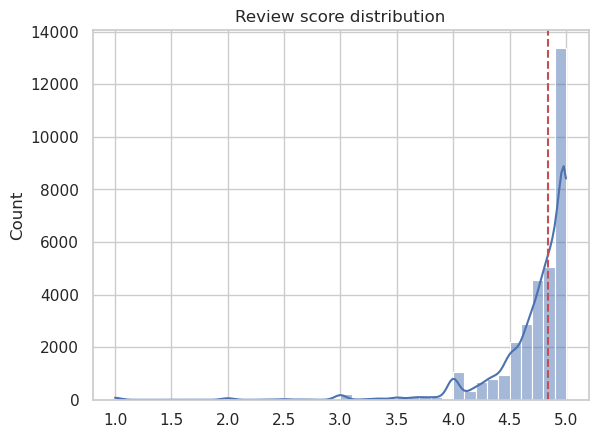

In [8]:
r = df["review_scores_rating"].drop_nulls()
print(r.describe())
print(f"share ≥ 4.5: {(r>=4.5).mean():.1%}   share ≥ 4.9: {(r>=4.9).mean():.1%}")
sns.histplot(r.to_numpy(), bins=40, kde=True); plt.axvline(r.median(), c="r", ls="--")
plt.title("Review score distribution")

In [9]:
av = df.group_by("city_key").agg(
        mean_avail=pl.col("availability_365").mean(),
        median_avail=pl.col("availability_365").median(),
        pct_zero=(pl.col("availability_365")==0).mean())
av.to_pandas()

,city_key,mean_avail,median_avail,pct_zero
0,mallorca,181.030236,171.0,0.018695
1,melbourne,165.968865,158.0,0.238116


## 4.2 Geographic & SpaBal Analysis

In [10]:
# distance to centre — vectorized Polars expression, no apply()
centre = pl.DataFrame({"city_key":list(CENTRES),
                       "lat0":[c[0] for c in CENTRES.values()],
                       "lon0":[c[1] for c in CENTRES.values()]})
R=6371
geo = (df.join(centre, on="city_key")
        .drop_nulls(["latitude","longitude"])
        .with_columns(
            dist_km = 2*R*(
                ( ((pl.col("lat0")-pl.col("latitude")).radians()/2).sin()**2
                + pl.col("latitude").radians().cos()*pl.col("lat0").radians().cos()
                  *((pl.col("lon0")-pl.col("longitude")).radians()/2).sin()**2
                ).sqrt().arcsin())))

In [11]:
def density_map(city):
    d = geo.filter(pl.col("city_key")==city)
    m = folium.Map(list(CENTRES[city]), zoom_start=11, tiles="cartodbpositron")
    HeatMap(d.select("latitude","longitude").to_numpy(), radius=7, blur=5).add_to(m)
    return m
density_map("melbourne")

melbourne: corr(dist,logprice)=0.02, ~0.3 price/km
mallorca: corr(dist,logprice)=-0.03, ~1.8 price/km


Text(0.5, 1.0, 'Median price vs distance')

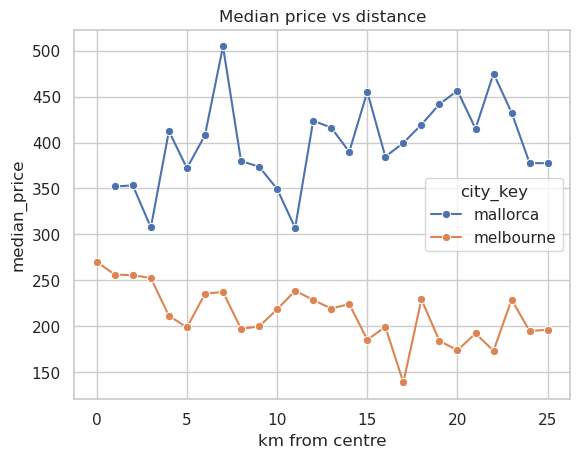

In [12]:
grad = (geo.filter(pl.col("price").is_not_null())
          .with_columns(band=(pl.col("dist_km")//1))
          .group_by("city_key","band").agg(median_price=pl.col("price").median(), n=pl.len())
          .filter(pl.col("n")>=5).sort("city_key","band"))

for city in CENTRES:
    d = geo.filter((pl.col("city_key")==city) & pl.col("price").is_not_null())
    corr = d.select(pl.corr("dist_km", pl.col("price").log1p())).item()
    slope = np.polyfit(d["dist_km"].to_numpy(), d["price"].to_numpy(), 1)[0]
    print(f"{city}: corr(dist,logprice)={corr:.2f}, ~{slope:.1f} price/km")

g = grad.to_pandas()
sns.lineplot(g[g.band<=25], x="band", y="median_price", hue="city_key", marker="o")
plt.xlabel("km from centre"); plt.title("Median price vs distance")

In [13]:
nb = (geo.filter(pl.col("review_scores_rating").is_not_null())
        .group_by("city_key","neighbourhood_std")
        .agg(lat=pl.col("latitude").median(), lon=pl.col("longitude").median(),
             rating=pl.col("review_scores_rating").mean(), n=pl.len())
        .filter(pl.col("n")>=20))

def rating_map(city):
    d = nb.filter(pl.col("city_key")==city)
    lo, hi = d["rating"].min(), d["rating"].max()
    m = folium.Map(list(CENTRES[city]), zoom_start=11, tiles="cartodbpositron")
    for row in d.iter_rows(named=True):
        f=(row["rating"]-lo)/(hi-lo+1e-9)
        folium.CircleMarker([row["lat"],row["lon"]], radius=5+row["n"]**0.4,
            color=f"#{int(255*(1-f)):02x}{int(160*f):02x}30", fill=True, fill_opacity=.7,
            popup=f'{row["neighbourhood_std"]}: {row["rating"]:.2f} (n={row["n"]})').add_to(m)
    return m
rating_map("melbourne")

clusters found: 16


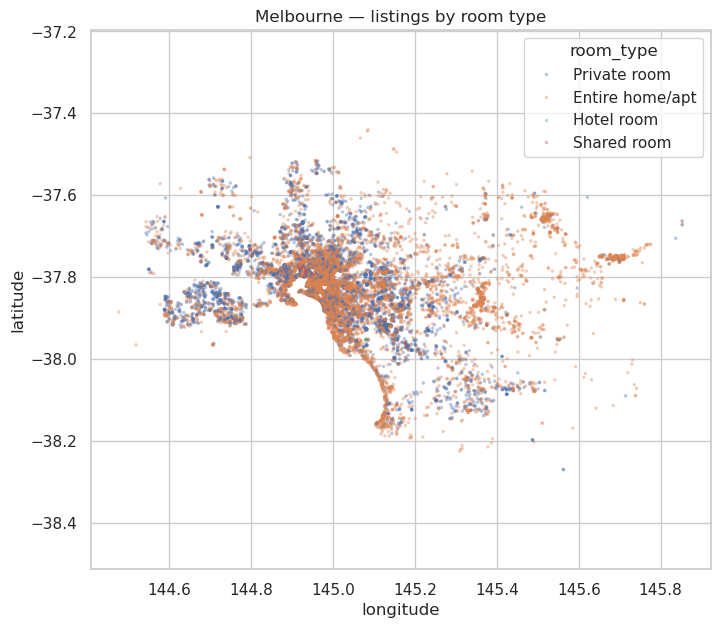

In [14]:
pdf = geo.filter(pl.col("city_key")=="melbourne").to_pandas()
plt.figure(figsize=(8,7))
sns.scatterplot(pdf, x="longitude", y="latitude", hue="room_type", s=6, alpha=.4, linewidth=0)
plt.axis("equal"); plt.title("Melbourne — listings by room type")

# optional DBSCAN to name actual clusters (ML step -> sklearn)
from sklearn.cluster import DBSCAN
d = geo.filter((pl.col("city_key")=="melbourne") & (pl.col("room_type")=="Entire home/apt"))
coords = np.radians(d.select("latitude","longitude").to_numpy())
lbl = DBSCAN(eps=0.3/6371, min_samples=30, metric="haversine").fit_predict(coords)
print("clusters found:", len(set(lbl))-(1 if -1 in lbl else 0))

Text(0.5, 1.0, "Price gradient ÷ each city's median")

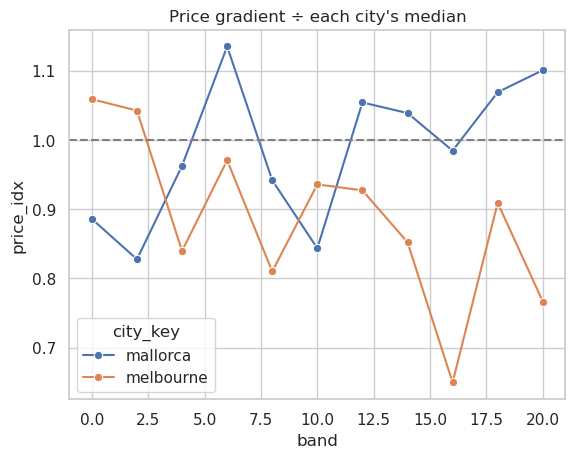

In [15]:
comp = (geo.filter(pl.col("price").is_not_null())
          .with_columns(price_idx=pl.col("price")/pl.col("price").median().over("city_key"),
                        band=(pl.col("dist_km")//2)*2)
          .group_by("city_key","band").agg(price_idx=pl.col("price_idx").median())
          .filter(pl.col("band")<=20).sort("city_key","band"))
sns.lineplot(comp.to_pandas(), x="band", y="price_idx", hue="city_key", marker="o")
plt.axhline(1, ls="--", c="grey"); plt.title("Price gradient ÷ each city's median")

# 4.3 Temporal & Seasonal

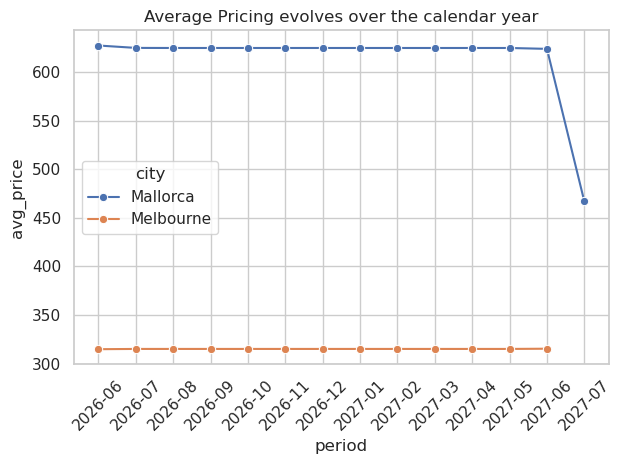

In [22]:
season = con.execute("""
    SELECT
        c.display_name AS city,
        d.year,
        d.month,
        AVG(l.price) AS avg_price,
    FROM fact_calendar cal
    JOIN fact_listing l
        ON cal.listing_id = l.listing_id
    JOIN dim_date d
        ON cal.date_key = d.date_key
    JOIN dim_city c
        ON l.city_key = c.city_key
    GROUP BY
        c.display_name,
        d.year,
        d.month
    ORDER BY
        c.display_name,
        d.year,
        d.month;
""").pl()

season = season.with_columns(
    period=(
        pl.col("year").cast(pl.String)
        + "-"
        + pl.col("month").cast(pl.String).str.zfill(2)
    )
)

sns.lineplot(
    data=season.to_pandas(),
    x="period",
    y="avg_price",
    hue="city",
    marker="o",
)

plt.xticks(rotation=45)
plt.title("Average Pricing evolves over the calendar year")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'reviews')

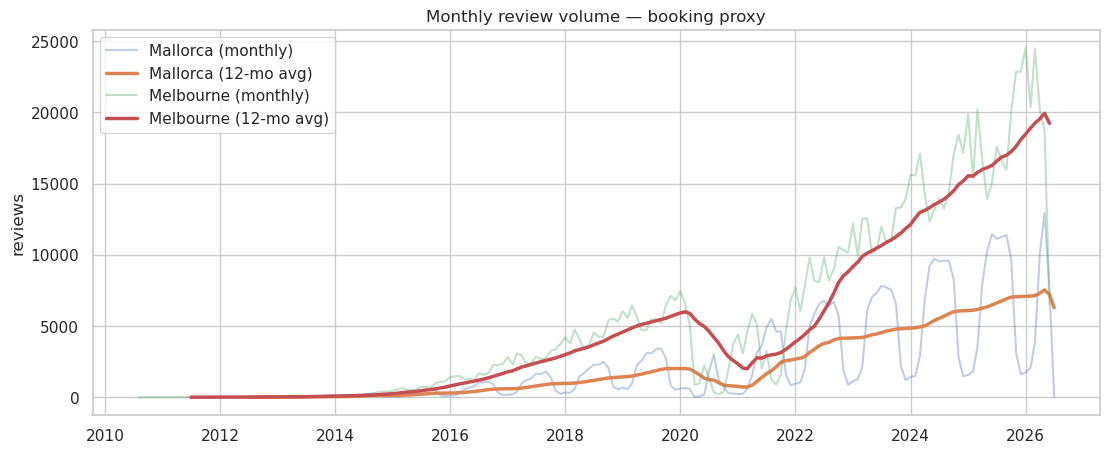

In [20]:
rev = con.execute("""
    SELECT c.display_name AS city, d.year, d.month,
           make_date(d.year, d.month, 1) AS month_start,
           count(*) AS reviews
    FROM fact_review f
    JOIN dim_date d ON d.date_key = f.date_key
    JOIN dim_city c ON c.city_key = f.city_key
    GROUP BY 1,2,3,4
    ORDER BY 1,4
""").pl()

rev = rev.sort("city","month_start").with_columns(
    roll12 = pl.col("reviews").rolling_mean(window_size=12).over("city"))

pdf = rev.to_pandas()
fig, ax = plt.subplots(figsize=(13,5))
for city, g in pdf.groupby("city"):
    ax.plot(g.month_start, g.reviews, alpha=.35, label=f"{city} (monthly)")
    ax.plot(g.month_start, g.roll12, lw=2.5, label=f"{city} (12-mo avg)")
ax.set_title("Monthly review volume — booking proxy"); ax.legend(); ax.set_ylabel("reviews")

Text(0, 0.5, 'median minimum nights')

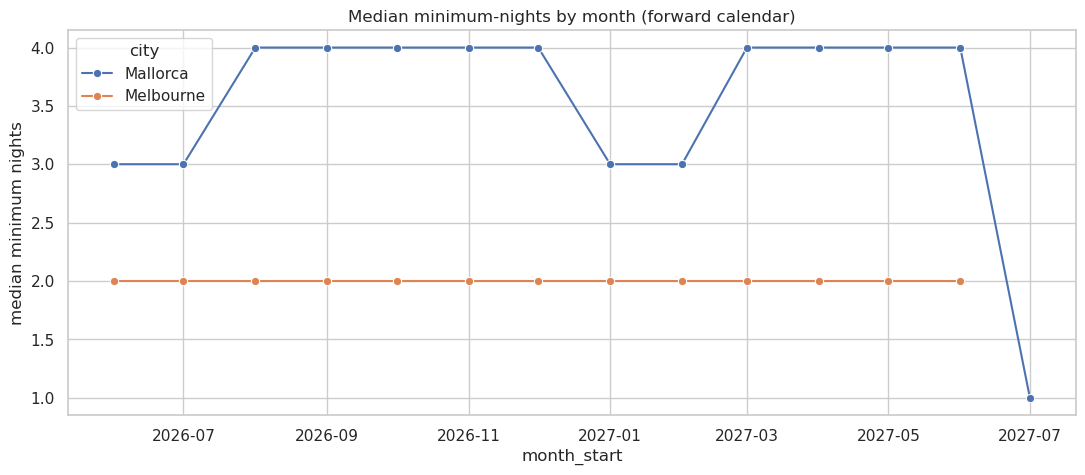

In [26]:
mn = con.execute("""
    SELECT c.display_name AS city, d.year, d.month,
           make_date(d.year, d.month, 1) AS month_start,
           median(cal.minimum_nights)                              AS median_min_nights,
           avg(cal.minimum_nights::DOUBLE)                         AS mean_min_nights,
           avg(CASE WHEN cal.minimum_nights >= 7 THEN 1.0 ELSE 0 END) AS share_weekly_plus,
           count(*)                                                AS listing_days
    FROM fact_calendar cal
    JOIN dim_date d ON d.date_key = cal.date_key
    JOIN dim_city c ON c.city_key = cal.city_key
    GROUP BY 1,2,3,4
    ORDER BY 1,4
""").pl()

pdf = mn.to_pandas()
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(pdf, x="month_start", y="median_min_nights", hue="city", marker="o", ax=ax)
ax.set_title("Median minimum-nights by month (forward calendar)")
ax.set_ylabel("median minimum nights")

# 4.4 Host & Supply-Side

In [29]:
host = con.execute("""
    SELECT c.display_name AS city, h.host_id,
           bool_or(h.host_is_superhost)        AS is_superhost,
           count(*)                            AS n_listings,
           median(f.price)                     AS median_price,
           sum(f.estimated_revenue_l365d)      AS est_revenue,
           avg(f.review_scores_rating)         AS avg_rating
    FROM fact_listing f
    JOIN dim_host h ON h.host_sk = f.host_sk
    JOIN dim_city c ON c.city_key = f.city_key
    GROUP BY 1,2
""").pl().with_columns(
    segment=pl.when(pl.col("n_listings")==1).then(pl.lit("Single (1)"))
             .when(pl.col("n_listings")<=3).then(pl.lit("Small (2-3)"))
             .when(pl.col("n_listings")<=9).then(pl.lit("Multi (4-9)"))
             .otherwise(pl.lit("Commercial (10+)")))

seg = (host.group_by("city","segment")
           .agg(hosts=pl.len(),
                listings=pl.col("n_listings").sum(),
                revenue=pl.col("est_revenue").sum(),
                median_price=pl.col("median_price").median())
           .with_columns(
                host_share=(pl.col("hosts")/pl.col("hosts").sum().over("city")*100).round(1),
                listing_share=(pl.col("listings")/pl.col("listings").sum().over("city")*100).round(1),
                revenue_share=(pl.col("revenue")/pl.col("revenue").sum().over("city")*100).round(1)))
order = ["Single (1)","Small (2-3)","Multi (4-9)","Commercial (10+)"]
print(seg.sort("city","segment"))

shape: (8, 9)
┌───────────┬────────────┬───────┬──────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ city      ┆ segment    ┆ hosts ┆ listings ┆ … ┆ median_pri ┆ host_share ┆ listing_sh ┆ revenue_s │
│ ---       ┆ ---        ┆ ---   ┆ ---      ┆   ┆ ce         ┆ ---        ┆ are        ┆ hare      │
│ str       ┆ str        ┆ u32   ┆ i64      ┆   ┆ ---        ┆ f64        ┆ ---        ┆ ---       │
│           ┆            ┆       ┆          ┆   ┆ f64        ┆            ┆ f64        ┆ f64       │
╞═══════════╪════════════╪═══════╪══════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ Mallorca  ┆ Commercial ┆ 215   ┆ 9037     ┆ … ┆ 457.8575   ┆ 5.5        ┆ 61.0       ┆ 41.5      │
│           ┆ (10+)      ┆       ┆          ┆   ┆            ┆            ┆            ┆           │
│ Mallorca  ┆ Multi      ┆ 287   ┆ 1561     ┆ … ┆ 275.645    ┆ 7.3        ┆ 10.5       ┆ 12.2      │
│           ┆ (4-9)      ┆       ┆          ┆   ┆            ┆            ┆  

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Single (1)'),
  Text(1, 0, 'Small (2-3)'),
  Text(2, 0, 'Multi (4-9)'),
  Text(3, 0, 'Commercial (10+)')])

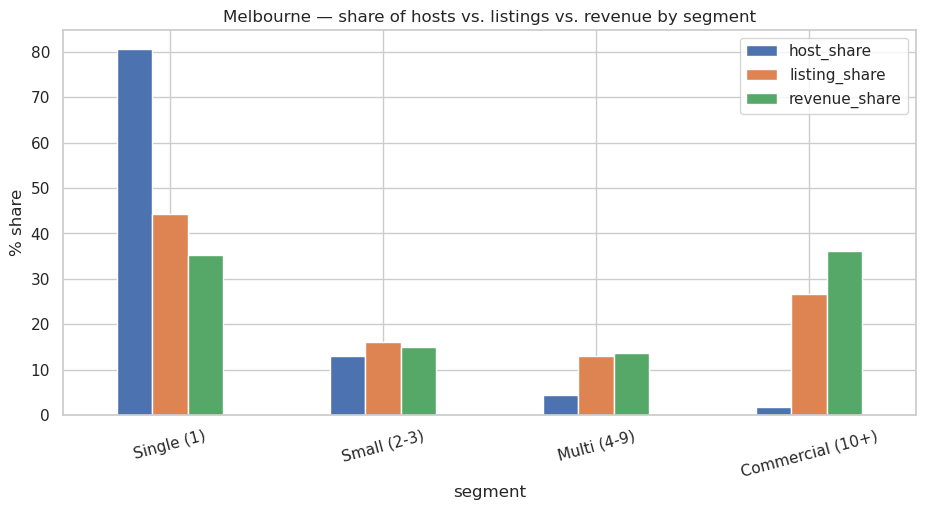

In [30]:
p = seg.filter(pl.col("city")=="Melbourne").to_pandas().set_index("segment").reindex(order)
ax = p[["host_share","listing_share","revenue_share"]].plot.bar(figsize=(11,5))
ax.set_title("Melbourne — share of hosts vs. listings vs. revenue by segment")
ax.set_ylabel("% share"); plt.xticks(rotation=15)

In [31]:
ph = (host.group_by("city").agg(
        top1  = (pl.col("n_listings").sort(descending=True)
                   .head(pl.col("n_listings").len()//100 + 1).sum()),
        total = pl.col("n_listings").sum()))
# cleaner: exact top-x% share via cumulative
for city in host["city"].unique():
    s = host.filter(pl.col("city")==city).sort("n_listings", descending=True)["n_listings"]
    tot = s.sum()
    for q in [0.01, 0.05, 0.10]:
        k = max(1, int(len(s)*q))
        print(f"{city}: top {q:.0%} of hosts control {s.head(k).sum()/tot:.1%} of listings")

Mallorca: top 1% of hosts control 31.0% of listings
Mallorca: top 5% of hosts control 59.6% of listings
Mallorca: top 10% of hosts control 68.5% of listings
Melbourne: top 1% of hosts control 20.8% of listings
Melbourne: top 5% of hosts control 36.7% of listings
Melbourne: top 10% of hosts control 45.5% of listings


shape: (12, 6)
┌───────────┬──────────────┬─────────────────┬──────────┬──────────────┬────────────┐
│ city      ┆ host_type    ┆ room_type       ┆ listings ┆ median_price ┆ median_ppb │
│ ---       ┆ ---          ┆ ---             ┆ ---      ┆ ---          ┆ ---        │
│ str       ┆ str          ┆ str             ┆ u32      ┆ f64          ┆ f64        │
╞═══════════╪══════════════╪═════════════════╪══════════╪══════════════╪════════════╡
│ Mallorca  ┆ Casual       ┆ Entire home/apt ┆ 2527     ┆ 366.0        ┆ 133.0      │
│ Mallorca  ┆ Professional ┆ Entire home/apt ┆ 7841     ┆ 433.57       ┆ 156.5      │
│ Mallorca  ┆ Professional ┆ Hotel room      ┆ 30       ┆ 244.0        ┆ 235.0      │
│ Mallorca  ┆ Casual       ┆ Private room    ┆ 56       ┆ 138.0        ┆ 88.75      │
│ Mallorca  ┆ Professional ┆ Private room    ┆ 603      ┆ 178.0        ┆ 156.0      │
│ Melbourne ┆ Casual       ┆ Entire home/apt ┆ 5299     ┆ 276.65       ┆ 161.0      │
│ Melbourne ┆ Professional ┆ Entire hom

([0, 1, 2, 3],
 [Text(0, 0, 'Entire home/apt'),
  Text(1, 0, 'Private room'),
  Text(2, 0, 'Hotel room'),
  Text(3, 0, 'Shared room')])

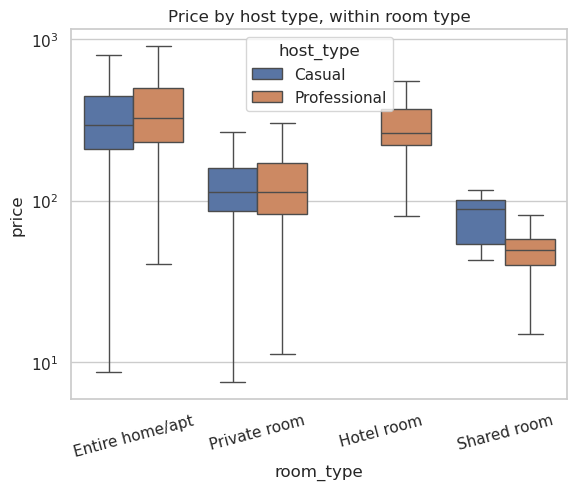

In [33]:
lf = con.execute("""
    WITH host_size AS (
        SELECT host_sk, count(*) AS n_listings
        FROM fact_listing GROUP BY 1
    )
    SELECT c.display_name AS city, f.listing_id,
           CASE WHEN hs.n_listings = 1 THEN 'Casual' ELSE 'Professional' END AS host_type,
           hs.n_listings, rt.room_type, p.property_family,
           f.price, f.price_per_bedroom, f.minimum_nights,
           f.estimated_occupancy_l365d, f.estimated_revenue_l365d,
           f.review_scores_rating, f.number_of_reviews
    FROM fact_listing f
    JOIN host_size hs      ON hs.host_sk = f.host_sk
    JOIN dim_city c        ON c.city_key = f.city_key
    JOIN dim_room_type rt  ON rt.room_type_sk = f.room_type_sk
    JOIN dim_property p    ON p.property_sk = f.property_sk
    WHERE f.price IS NOT NULL
""").pl()

comp = (lf.group_by("city","host_type","room_type")
          .agg(listings=pl.len(), median_price=pl.col("price").median(),
               median_ppb=pl.col("price_per_bedroom").median()))
print(comp.sort("city","room_type","host_type"))

pdf = lf.filter(pl.col("price") < lf["price"].quantile(.99)).to_pandas()
sns.boxplot(pdf, x="room_type", y="price", hue="host_type", showfliers=False)
plt.yscale("log"); plt.title("Price by host type, within room type"); plt.xticks(rotation=15)

In [34]:
disp = (lf.group_by("city","host_type")
          .agg(cv=(pl.col("price").std()/pl.col("price").mean()).round(3),   # coeff. of variation
               iqr=(pl.col("price").quantile(.75)-pl.col("price").quantile(.25)),
               round_pricing=(pl.col("price")%10==0).mean().round(3)))       # % priced at round tens
print(disp.sort("city","host_type"))

shape: (4, 5)
┌───────────┬──────────────┬───────┬────────┬───────────────┐
│ city      ┆ host_type    ┆ cv    ┆ iqr    ┆ round_pricing │
│ ---       ┆ ---          ┆ ---   ┆ ---    ┆ ---           │
│ str       ┆ str          ┆ f64   ┆ f64    ┆ f64           │
╞═══════════╪══════════════╪═══════╪════════╪═══════════════╡
│ Mallorca  ┆ Casual       ┆ 1.152 ┆ 355.75 ┆ 0.058         │
│ Mallorca  ┆ Professional ┆ 1.289 ┆ 475.0  ┆ 0.085         │
│ Melbourne ┆ Casual       ┆ 1.749 ┆ 193.61 ┆ 0.06          │
│ Melbourne ┆ Professional ┆ 1.726 ┆ 188.0  ┆ 0.083         │
└───────────┴──────────────┴───────┴────────┴───────────────┘


In [35]:
outcome = (lf.group_by("city","host_type")
             .agg(median_price=pl.col("price").median(),
                  median_occ=pl.col("estimated_occupancy_l365d").median(),
                  median_rev=pl.col("estimated_revenue_l365d").median(),
                  median_minnights=pl.col("minimum_nights").median()))
print(outcome.sort("city","host_type"))

shape: (4, 6)
┌───────────┬──────────────┬──────────────┬────────────┬────────────┬──────────────────┐
│ city      ┆ host_type    ┆ median_price ┆ median_occ ┆ median_rev ┆ median_minnights │
│ ---       ┆ ---          ┆ ---          ┆ ---        ┆ ---        ┆ ---              │
│ str       ┆ str          ┆ f64          ┆ f64        ┆ f64        ┆ f64              │
╞═══════════╪══════════════╪══════════════╪════════════╪════════════╪══════════════════╡
│ Mallorca  ┆ Casual       ┆ 359.6        ┆ 54.0       ┆ 18260.0    ┆ 3.0              │
│ Mallorca  ┆ Professional ┆ 408.415      ┆ 20.0       ┆ 8613.5     ┆ 2.0              │
│ Melbourne ┆ Casual       ┆ 236.5        ┆ 36.0       ┆ 9264.0     ┆ 2.0              │
│ Melbourne ┆ Professional ┆ 247.5        ┆ 36.0       ┆ 8256.0     ┆ 2.0              │
└───────────┴──────────────┴──────────────┴────────────┴────────────┴──────────────────┘


In [36]:
ph = con.execute("""
    SELECT c.display_name AS city, h.host_id, count(*) AS n_listings
    FROM fact_listing f
    JOIN dim_host h ON h.host_sk = f.host_sk
    JOIN dim_city c ON c.city_key = f.city_key
    GROUP BY 1,2
""").pl()

for city in ph["city"].unique().sort():
    s = ph.filter(pl.col("city")==city).sort("n_listings", descending=True)["n_listings"].to_numpy()
    tot, nh = s.sum(), len(s)
    cum = np.cumsum(s) / tot
    hosts_to_half = int(np.searchsorted(cum, 0.50)) + 1     # hosts holding the first 50% of supply
    print(f"{city}: {hosts_to_half/nh:.1%} of hosts control 50% of listings "
          f"({hosts_to_half:,} of {nh:,} hosts)")
    for q in [0.01, 0.05, 0.10]:
        k = max(1, int(nh*q))
        print(f"    top {q:.0%} of hosts -> {s[:k].sum()/tot:.1%} of listings")

Mallorca: 2.8% of hosts control 50% of listings (108 of 3,907 hosts)
    top 1% of hosts -> 31.0% of listings
    top 5% of hosts -> 59.6% of listings
    top 10% of hosts -> 68.5% of listings
Melbourne: 14.1% of hosts control 50% of listings (1,990 of 14,112 hosts)
    top 1% of hosts -> 20.8% of listings
    top 5% of hosts -> 36.7% of listings
    top 10% of hosts -> 45.5% of listings


# 4.5 Review & Demand-Side

Text(0.5, 1.0, 'Spearman correlations')

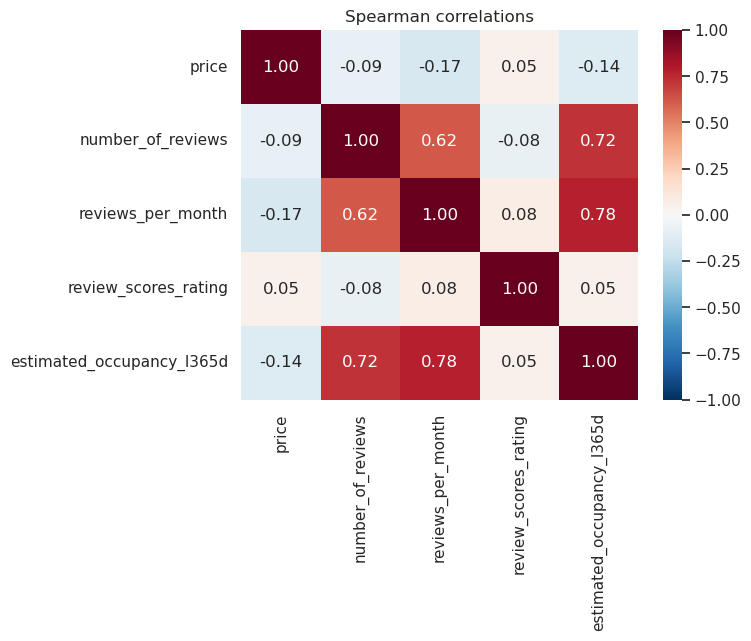

In [39]:
df = con.execute("""
    SELECT c.display_name AS city, rt.room_type,
           f.price, f.number_of_reviews, f.reviews_per_month,
           f.review_scores_rating, f.estimated_occupancy_l365d
    FROM fact_listing f
    JOIN dim_city c       ON c.city_key = f.city_key
    JOIN dim_room_type rt ON rt.room_type_sk = f.room_type_sk
    WHERE f.price IS NOT NULL
""").pl()

feats = ["price","number_of_reviews","reviews_per_month","review_scores_rating","estimated_occupancy_l365d"]
corr = df.select(feats).drop_nulls().to_pandas().corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlations")

In [40]:
df = con.execute("""
    SELECT c.display_name AS city, rt.room_type, p.property_family, n.neighbourhood,
           f.reviews_per_month, f.price, f.review_scores_rating,
           f.estimated_occupancy_l365d, f.availability_365, f.minimum_nights
    FROM fact_listing f
    JOIN dim_city c          ON c.city_key = f.city_key
    JOIN dim_room_type rt    ON rt.room_type_sk = f.room_type_sk
    JOIN dim_property p      ON p.property_sk = f.property_sk
    JOIN dim_neighbourhood n ON n.neighbourhood_sk = f.neighbourhood_sk
    WHERE f.price IS NOT NULL
""").pl()

v = df.filter(pl.col("reviews_per_month").is_not_null()
              & pl.col("estimated_occupancy_l365d").is_not_null())
corr = v.select(pl.corr("reviews_per_month", "estimated_occupancy_l365d")).item()
print(f"corr(reviews_per_month, estimated_occupancy) = {corr:.2f}")

# convert reviews/month -> implied bookings using a review rate assumption
REVIEW_RATE = 0.5   # ~50% of stays leave a review (state this assumption)
v = v.with_columns(implied_bookings_pm = pl.col("reviews_per_month")/REVIEW_RATE)

corr(reviews_per_month, estimated_occupancy) = 0.73


shape: (7, 5)
┌───────────┬─────────────────┬────────────┬──────────────┬───────┐
│ city      ┆ room_type       ┆ median_rpm ┆ median_price ┆ n     │
│ ---       ┆ ---             ┆ ---        ┆ ---          ┆ ---   │
│ str       ┆ str             ┆ f64        ┆ f64          ┆ u32   │
╞═══════════╪═════════════════╪════════════╪══════════════╪═══════╡
│ Mallorca  ┆ Private room    ┆ 0.49       ┆ 176.0        ┆ 659   │
│ Mallorca  ┆ Hotel room      ┆ 0.43       ┆ 244.0        ┆ 30    │
│ Mallorca  ┆ Entire home/apt ┆ 0.35       ┆ 416.0        ┆ 10368 │
│ Melbourne ┆ Entire home/apt ┆ 1.09       ┆ 280.5        ┆ 14472 │
│ Melbourne ┆ Private room    ┆ 0.3        ┆ 108.55       ┆ 4454  │
│ Melbourne ┆ Shared room     ┆ 0.09       ┆ 49.8         ┆ 207   │
│ Melbourne ┆ Hotel room      ┆ 0.09       ┆ 324.0        ┆ 41    │
└───────────┴─────────────────┴────────────┴──────────────┴───────┘


([0, 1, 2, 3],
 [Text(0, 0, 'Private room'),
  Text(1, 0, 'Hotel room'),
  Text(2, 0, 'Entire home/apt'),
  Text(3, 0, 'Shared room')])

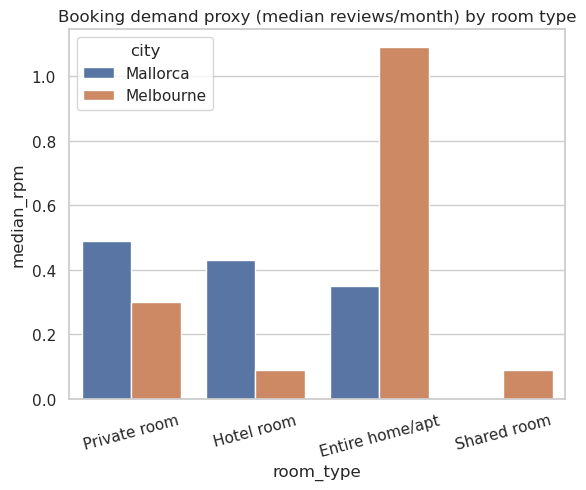

In [41]:
demand = (df.filter(pl.col("reviews_per_month").is_not_null())
            .group_by("city","room_type")
            .agg(median_rpm=pl.col("reviews_per_month").median(),
                 median_price=pl.col("price").median(), n=pl.len())
            .sort("city","median_rpm", descending=[False,True]))
print(demand)

sns.barplot(demand.to_pandas(), x="room_type", y="median_rpm", hue="city")
plt.title("Booking demand proxy (median reviews/month) by room type"); plt.xticks(rotation=15)

Text(0, 0.5, 'median reviews/month')

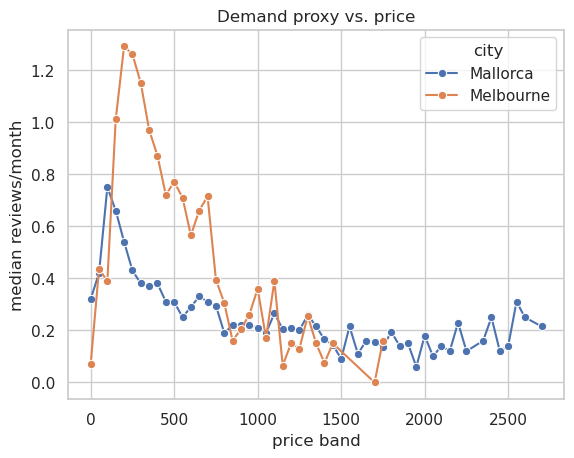

In [42]:
d = df.filter(pl.col("reviews_per_month").is_not_null()
              & (pl.col("price") < df["price"].quantile(.99)))
curve = (d.with_columns(price_band=(pl.col("price")//50*50))
           .group_by("city","price_band")
           .agg(median_rpm=pl.col("reviews_per_month").median(), n=pl.len())
           .filter(pl.col("n")>=10).sort("city","price_band"))
sns.lineplot(curve.to_pandas(), x="price_band", y="median_rpm", hue="city", marker="o")
plt.title("Demand proxy vs. price"); plt.xlabel("price band"); plt.ylabel("median reviews/month")

In [43]:
flags = (df.filter(pl.col("reviews_per_month").is_not_null())
           .with_columns(
                low_demand=(pl.col("reviews_per_month") < 0.2),
                rarely_available=(pl.col("availability_365") < 30),
                high_minnights=(pl.col("minimum_nights") >= 7))
           .group_by("city")
           .agg(share_low_demand=pl.col("low_demand").mean().round(3),
                low_but_blocked=(pl.col("low_demand") & pl.col("rarely_available")).mean().round(3),
                low_but_longstay=(pl.col("low_demand") & pl.col("high_minnights")).mean().round(3)))
print(flags)

shape: (2, 4)
┌───────────┬──────────────────┬─────────────────┬──────────────────┐
│ city      ┆ share_low_demand ┆ low_but_blocked ┆ low_but_longstay │
│ ---       ┆ ---              ┆ ---             ┆ ---              │
│ str       ┆ f64              ┆ f64             ┆ f64              │
╞═══════════╪══════════════════╪═════════════════╪══════════════════╡
│ Mallorca  ┆ 0.368            ┆ 0.025           ┆ 0.07             │
│ Melbourne ┆ 0.248            ┆ 0.01            ┆ 0.043            │
└───────────┴──────────────────┴─────────────────┴──────────────────┘


                              mean
review_scores_value          4.642
review_scores_cleanliness    4.683
review_scores_accuracy       4.752
review_scores_location       4.792
review_scores_checkin        4.799
review_scores_communication  4.811


(4.0, 5.0)

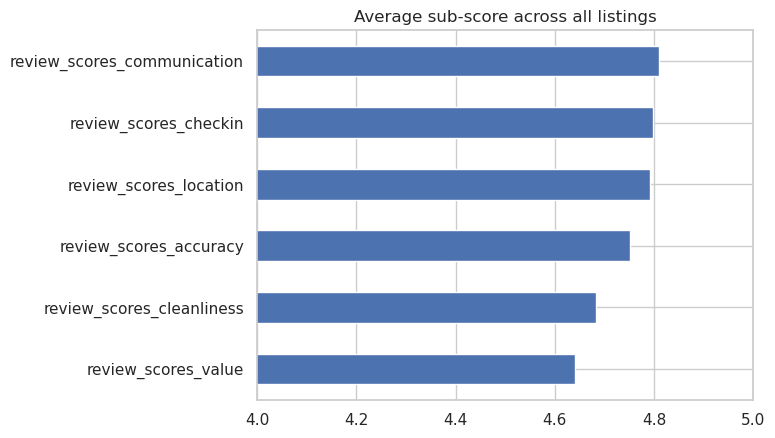

In [46]:
SUBS = ["review_scores_accuracy","review_scores_cleanliness","review_scores_checkin",
        "review_scores_communication","review_scores_location","review_scores_value"]

df = con.execute(f"""
    SELECT c.display_name AS city, rt.room_type,
           f.price, f.review_scores_rating, f.number_of_reviews,
           {", ".join("f."+s for s in SUBS)}
    FROM fact_listing f
    JOIN dim_city c       ON c.city_key = f.city_key
    JOIN dim_room_type rt ON rt.room_type_sk = f.room_type_sk
""").pl()

means = (df.select([pl.col(s).mean().alias(s) for s in SUBS])
           .to_pandas().T.rename(columns={0:"mean"}).sort_values("mean"))
print(means.round(3))

means.plot.barh(legend=False); plt.title("Average sub-score across all listings")
plt.xlim(4.0, 5.0)   # zoom: they're all inflated, differences live in the top band

shape: (2, 7)
┌───────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ city      ┆ review_score ┆ review_score ┆ review_score ┆ review_scor ┆ review_scor ┆ review_scor │
│ ---       ┆ s_accuracy   ┆ s_cleanlines ┆ s_checkin    ┆ es_communic ┆ es_location ┆ es_value    │
│ str       ┆ ---          ┆ s            ┆ ---          ┆ ation       ┆ ---         ┆ ---         │
│           ┆ f64          ┆ ---          ┆ f64          ┆ ---         ┆ f64         ┆ f64         │
│           ┆              ┆ f64          ┆              ┆ f64         ┆             ┆             │
╞═══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ Mallorca  ┆ 4.725        ┆ 4.673        ┆ 4.802        ┆ 4.767       ┆ 4.716       ┆ 4.562       │
│ Melbourne ┆ 4.767        ┆ 4.688        ┆ 4.797        ┆ 4.835       ┆ 4.834       ┆ 4.685       │
└───────────┴──────────────┴──────────────┴──────────────┴─────────────┴─────

(array([0.5, 1.5]), [Text(0, 0.5, 'Mallorca'), Text(0, 1.5, 'Melbourne')])

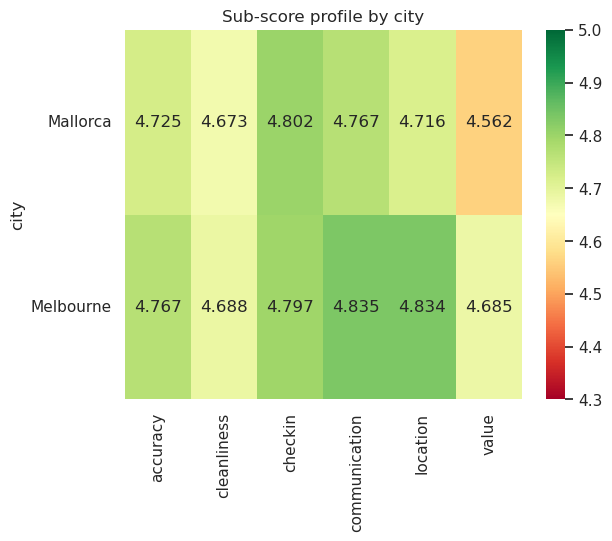

In [47]:
prof = (df.group_by("city").agg([pl.col(s).mean().round(3).alias(s) for s in SUBS]))
print(prof)

# radar-ish comparison via a heatmap (cleaner than a radar at this scale)
m = prof.to_pandas().set_index("city")[SUBS]
m.columns = [c.replace("review_scores_","") for c in m.columns]
sns.heatmap(m, annot=True, fmt=".3f", cmap="RdYlGn", vmin=4.3, vmax=5.0)
plt.title("Sub-score profile by city"); plt.yticks(rotation=0)

In [48]:
sub = df.drop_nulls(SUBS + ["review_scores_rating"])
corr = sub.select([pl.corr(s, "review_scores_rating").alias(s.replace("review_scores_","")) for s in SUBS])
print(corr.to_pandas().T.rename(columns={0:"corr_with_overall"}).sort_values("corr_with_overall", ascending=False).round(3))

               corr_with_overall
accuracy                   0.865
value                      0.856
cleanliness                0.813
communication              0.766
checkin                    0.675
location                   0.605


In [49]:
import statsmodels.formula.api as smf
d = df.filter(pl.col("price").is_not_null() & (pl.col("price")>0)).drop_nulls(SUBS).to_pandas()
d["log_price"] = np.log(d["price"])
d = d.rename(columns={s: s.replace("review_scores_","rs_") for s in SUBS})
model = smf.ols("log_price ~ rs_location + rs_cleanliness + rs_value + rs_communication + rs_accuracy + rs_checkin", data=d).fit()
print(model.params.round(3)); print(f"R² = {model.rsquared:.3f}")

Intercept           5.343
rs_location         0.011
rs_cleanliness      0.241
rs_value           -0.413
rs_communication   -0.069
rs_accuracy         0.285
rs_checkin          0.006
dtype: float64
R² = 0.020
